# EXPLORATORY DATA ANALYSIS

In [121]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import RobustScaler

plt.style.use("seaborn-v0_8")

# Config
INPUT_FILE = "Final_Merged_2023_2025_Hourly.csv"
TARGET = "PM2.5"

POLLUTANTS = ["PM2.5","PM10","NO","NO2","NOx","NH3","SO2","CO","Ozone","Benzene","Toluene"]
WEATHER = ["RH","WS","WD","SR","BP","AT","VWS","TOT-RF","RF"]

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

In [122]:
df = pd.read_csv(INPUT_FILE)

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y %H:%M")
df = df.sort_values(["City","Date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Cities:", df["City"].unique())
df.head()

Shape: (210432, 22)
Cities: ['Amaravati' 'Anantapur' 'Chittoor' 'Kadapa' 'Rajamahendravaram'
 'Tirupati' 'Vijayawada' 'Visakhapatnam']


,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,Toluene,RH,WS,WD,SR,BP,VWS,TOT-RF,RF,AT
0,2023-01-01 00:00:00,Amaravati,42.50,79.0,1.725000,11.625,7.600000,15.650000,11.825000,0.630000,...,2.000,96.500000,0.200000,74.25,11.0,761.5,0.0,0.0,0.0,22.175000
1,2023-01-01 01:00:00,Amaravati,41.75,79.0,2.175000,12.125,8.200000,15.400000,11.500000,0.582500,...,2.450,97.000000,0.200000,102.25,11.0,761.0,0.0,0.0,0.0,21.925000
2,2023-01-01 02:00:00,Amaravati,44.50,79.0,1.100000,13.075,7.825000,15.375000,11.600000,0.582500,...,2.075,97.500000,0.400000,88.25,11.0,760.5,0.0,0.0,0.0,21.825000
3,2023-01-01 03:00:00,Amaravati,50.00,79.0,1.066667,12.800,7.666667,15.466667,11.566667,0.673333,...,2.700,97.666667,0.633333,89.00,11.0,760.0,0.0,0.0,0.0,21.766667
4,2023-01-01 04:00:00,Amaravati,51.50,79.0,0.825000,10.325,6.150000,16.300000,10.725000,0.602500,...,3.050,98.000000,0.625000,92.00,11.0,760.0,0.0,0.0,0.0,21.700000


In [123]:
# Missing %
missing = df.isna().mean()*100
missing.sort_values(ascending=False).head(10)

,0
VWS,20.118138
NO,16.127300
PM2.5,15.403551
NH3,15.323715
PM10,15.278570
NO2,14.703562
Ozone,14.550544
NOx,14.520130
CO,13.716545
SO2,13.354908


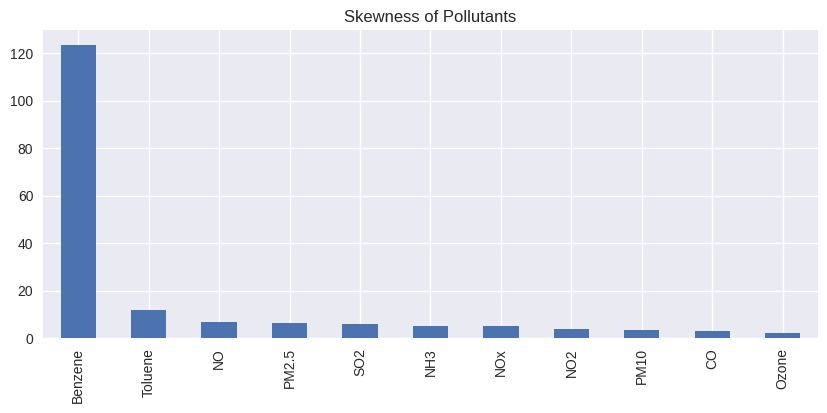

In [124]:
skew = df[POLLUTANTS].skew().sort_values(ascending=False)

plt.figure(figsize=(10,4))
skew.plot(kind="bar")
plt.title("Skewness of Pollutants")
plt.show()

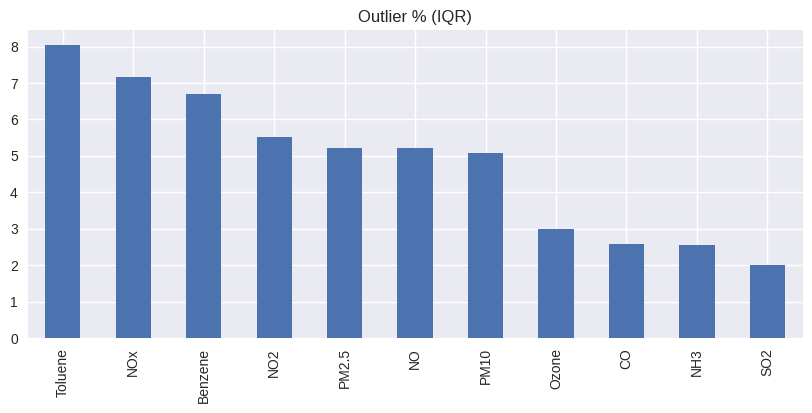

In [125]:
outliers = {}

for col in POLLUTANTS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    n = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    outliers[col] = n / len(df) * 100

outliers = pd.Series(outliers).sort_values(ascending=False)

plt.figure(figsize=(10,4))
outliers.plot(kind="bar")
plt.title("Outlier % (IQR)")
plt.show()

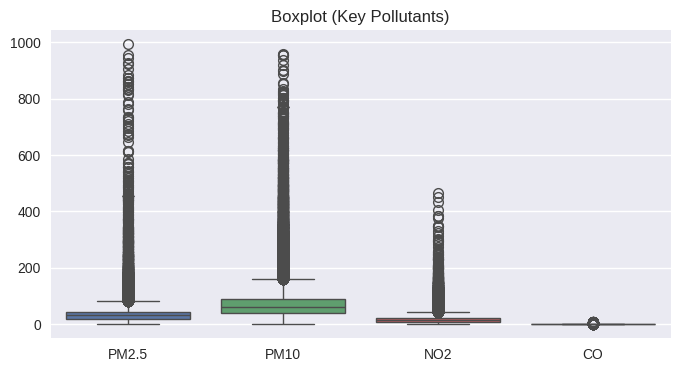

In [126]:
# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(data=df[["PM2.5","PM10","NO2","CO"]])
plt.title("Boxplot (Key Pollutants)")
plt.show()

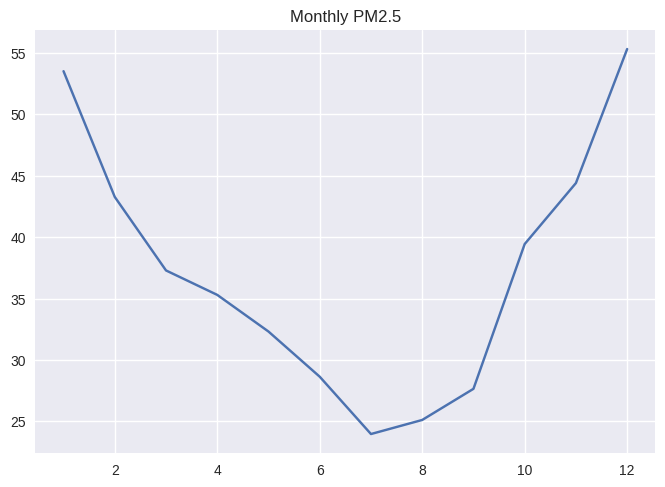

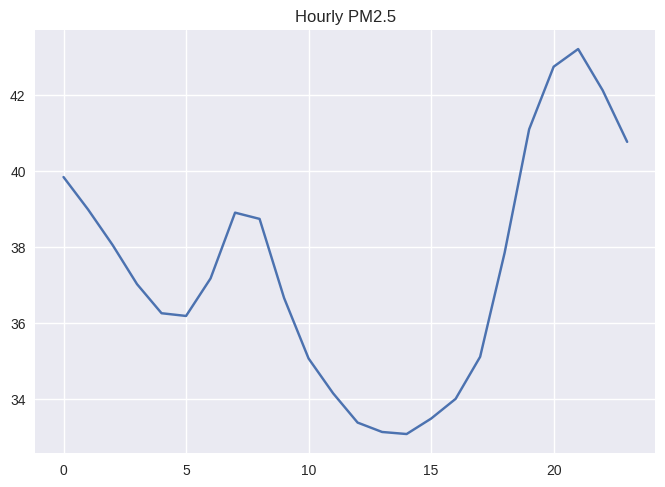

In [127]:
df["Month"] = df["Date"].dt.month
df["Hour"] = df["Date"].dt.hour

# Monthly
month_avg = df.groupby("Month")["PM2.5"].mean()

plt.plot(month_avg)
plt.title("Monthly PM2.5")
plt.show()

# Hourly
hour_avg = df.groupby("Hour")["PM2.5"].mean()

plt.plot(hour_avg)
plt.title("Hourly PM2.5")
plt.show()

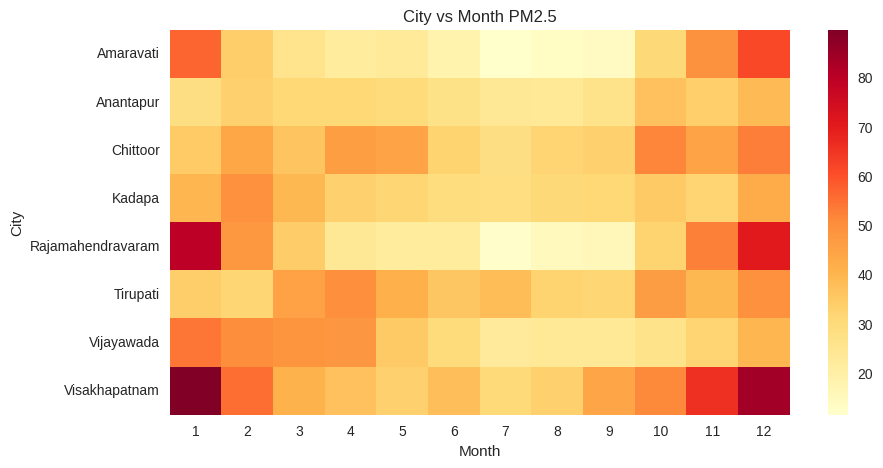

In [128]:
heat = df.groupby(["City","Month"])["PM2.5"].mean().unstack()

plt.figure(figsize=(10,5))
sns.heatmap(heat, cmap="YlOrRd")
plt.title("City vs Month PM2.5")
plt.show()

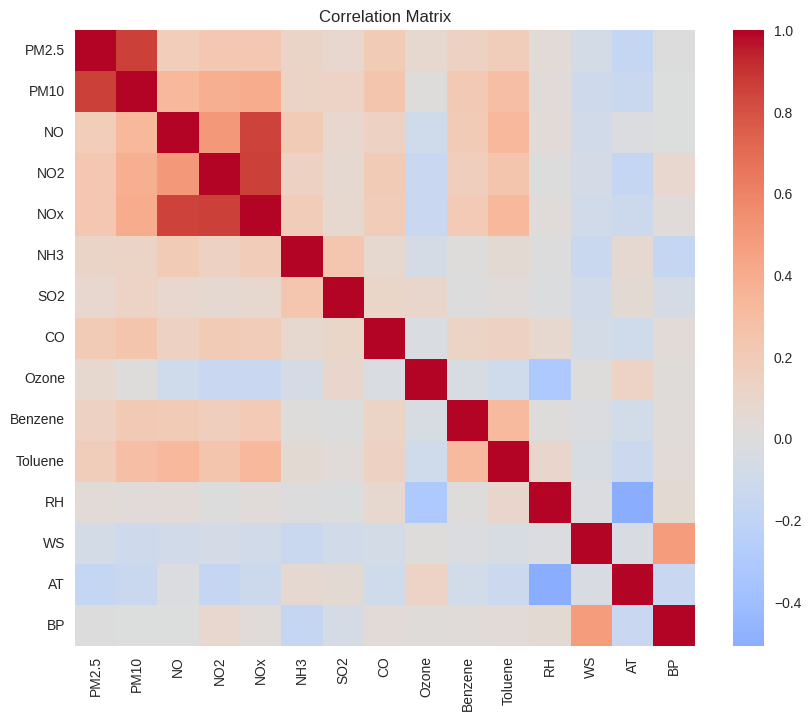

In [129]:
corr = df[POLLUTANTS + ["RH","WS","AT","BP"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [130]:
cols = POLLUTANTS + WEATHER

high_missing = [c for c in cols if df[c].isna().mean() > 0.1]

for col in high_missing:
    df[f"{col}_missing"] = df[col].isna().astype(int)


In [131]:
df.head()

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,Benzene_missing,Toluene_missing,RH_missing,WS_missing,WD_missing,SR_missing,BP_missing,AT_missing,VWS_missing,RF_missing
0,2023-01-01 00:00:00,Amaravati,42.50,79.0,1.725000,11.625,7.600000,15.650000,11.825000,0.630000,...,0,0,0,0,0,0,0,0,0,0
1,2023-01-01 01:00:00,Amaravati,41.75,79.0,2.175000,12.125,8.200000,15.400000,11.500000,0.582500,...,0,0,0,0,0,0,0,0,0,0
2,2023-01-01 02:00:00,Amaravati,44.50,79.0,1.100000,13.075,7.825000,15.375000,11.600000,0.582500,...,0,0,0,0,0,0,0,0,0,0
3,2023-01-01 03:00:00,Amaravati,50.00,79.0,1.066667,12.800,7.666667,15.466667,11.566667,0.673333,...,0,0,0,0,0,0,0,0,0,0
4,2023-01-01 04:00:00,Amaravati,51.50,79.0,0.825000,10.325,6.150000,16.300000,10.725000,0.602500,...,0,0,0,0,0,0,0,0,0,0


In [132]:
df["VWS_direction"] = np.sign(df["VWS"]).fillna(0)
df["VWS"] = df["VWS"].fillna(0)

In [133]:
df.head()

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,Toluene_missing,RH_missing,WS_missing,WD_missing,SR_missing,BP_missing,AT_missing,VWS_missing,RF_missing,VWS_direction
0,2023-01-01 00:00:00,Amaravati,42.50,79.0,1.725000,11.625,7.600000,15.650000,11.825000,0.630000,...,0,0,0,0,0,0,0,0,0,0.0
1,2023-01-01 01:00:00,Amaravati,41.75,79.0,2.175000,12.125,8.200000,15.400000,11.500000,0.582500,...,0,0,0,0,0,0,0,0,0,0.0
2,2023-01-01 02:00:00,Amaravati,44.50,79.0,1.100000,13.075,7.825000,15.375000,11.600000,0.582500,...,0,0,0,0,0,0,0,0,0,0.0
3,2023-01-01 03:00:00,Amaravati,50.00,79.0,1.066667,12.800,7.666667,15.466667,11.566667,0.673333,...,0,0,0,0,0,0,0,0,0,0.0
4,2023-01-01 04:00:00,Amaravati,51.50,79.0,0.825000,10.325,6.150000,16.300000,10.725000,0.602500,...,0,0,0,0,0,0,0,0,0,0.0


In [134]:
def handle_missing(df):
    dfs = []
    cols = POLLUTANTS + WEATHER

    for city in df["City"].unique():
        cdf = df[df["City"] == city].sort_values("Date").copy()
        cdf = cdf.set_index("Date")

        for col in cols:
            cdf[col] = cdf[col].interpolate(method="time")
            cdf[col] = cdf[col].ffill().bfill()

        cdf = cdf.reset_index()
        dfs.append(cdf)

    return pd.concat(dfs).reset_index(drop=True)

df = handle_missing(df)

In [135]:
df.head()

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,Toluene_missing,RH_missing,WS_missing,WD_missing,SR_missing,BP_missing,AT_missing,VWS_missing,RF_missing,VWS_direction
0,2023-01-01 00:00:00,Amaravati,42.50,79.0,1.725000,11.625,7.600000,15.650000,11.825000,0.630000,...,0,0,0,0,0,0,0,0,0,0.0
1,2023-01-01 01:00:00,Amaravati,41.75,79.0,2.175000,12.125,8.200000,15.400000,11.500000,0.582500,...,0,0,0,0,0,0,0,0,0,0.0
2,2023-01-01 02:00:00,Amaravati,44.50,79.0,1.100000,13.075,7.825000,15.375000,11.600000,0.582500,...,0,0,0,0,0,0,0,0,0,0.0
3,2023-01-01 03:00:00,Amaravati,50.00,79.0,1.066667,12.800,7.666667,15.466667,11.566667,0.673333,...,0,0,0,0,0,0,0,0,0,0.0
4,2023-01-01 04:00:00,Amaravati,51.50,79.0,0.825000,10.325,6.150000,16.300000,10.725000,0.602500,...,0,0,0,0,0,0,0,0,0,0.0


In [136]:
# Verify _missing flags survived handle_missing()
missing_cols = [c for c in df.columns if "_missing" in c]
print(f"Missing flag columns: {len(missing_cols)}")
print(missing_cols)

Missing flag columns: 19
['PM2.5_missing', 'PM10_missing', 'NO_missing', 'NO2_missing', 'NOx_missing', 'NH3_missing', 'SO2_missing', 'CO_missing', 'Ozone_missing', 'Benzene_missing', 'Toluene_missing', 'RH_missing', 'WS_missing', 'WD_missing', 'SR_missing', 'BP_missing', 'AT_missing', 'VWS_missing', 'RF_missing']


In [137]:
CLIP = {
    "Benzene": 4.47,
    "Toluene": 22.57,
    "NO": 53.23,
    "NO2": 81.51
}

def clip_outliers(df):
    df = df.copy()

    for col, th in CLIP.items():
        df[col] = df[col].clip(upper=th)

    return df

df = clip_outliers(df)

In [138]:
df["PM_ratio"] = (df["PM2.5"] / (df["PM10"] + 1)).clip(0, 10)
df["NO2_NOx_ratio"] = (df["NO2"] / (df["NOx"] + 1)).clip(0, 5)
df["Ventilation"] = df["WS"] * (df["AT"] + 273.15)

In [139]:
#Log-transform highly skewed features BEFORE scaling
import numpy as np

SKEWED_COLS = ["Benzene", "Toluene", "CO", "NO", "NOx", "NH3", "SO2"]

def log_transform(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))  # log1p handles zeros safely
    return df

df = log_transform(df, SKEWED_COLS)
print("Log transform applied to:", SKEWED_COLS)

Log transform applied to: ['Benzene', 'Toluene', 'CO', 'NO', 'NOx', 'NH3', 'SO2']


In [140]:
SEASON_MAP = {
    12:"Winter",1:"Winter",2:"Winter",
    3:"PreMonsoon",4:"PreMonsoon",5:"PreMonsoon",
    6:"Monsoon",7:"Monsoon",8:"Monsoon",
    9:"PostMonsoon",10:"PostMonsoon",11:"PostMonsoon"
}

df["Month"] = df["Date"].dt.month
df["Season"] = df["Month"].map(SEASON_MAP)
df["Season_ord"] = df["Season"].map({
    "Winter": 0, "PreMonsoon": 1, "Monsoon": 2, "PostMonsoon": 3
})

In [141]:
df["Hour"] = df["Date"].dt.hour
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Cyclical encoding
df["Hour_sin"] = np.sin(2*np.pi*df["Hour"]/24)
df["Hour_cos"] = np.cos(2*np.pi*df["Hour"]/24)
df["Month_sin"] = np.sin(2*np.pi*df["Month"]/12)
df["Month_cos"] = np.cos(2*np.pi*df["Month"]/12)

df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Day_sin"] = np.sin(2*np.pi*df["DayOfWeek"]/7)
df["Day_cos"] = np.cos(2*np.pi*df["DayOfWeek"]/7)

df["WD_sin"] = np.sin(np.deg2rad(df["WD"]))
df["WD_cos"] = np.cos(np.deg2rad(df["WD"]))
df.head()

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,DayOfWeek,Year,Hour_sin,Hour_cos,Month_sin,Month_cos,Day_sin,Day_cos,WD_sin,WD_cos
0,2023-01-01 00:00:00,Amaravati,42.50,79.0,1.002468,11.625,2.151762,2.812410,2.551396,0.488580,...,6,2023,0.000000,1.000000,0.5,0.866025,-0.781831,0.62349,0.962455,0.271440
1,2023-01-01 01:00:00,Amaravati,41.75,79.0,1.155308,12.125,2.219203,2.797281,2.525729,0.459006,...,6,2023,0.258819,0.965926,0.5,0.866025,-0.781831,0.62349,0.977231,-0.212178
2,2023-01-01 02:00:00,Amaravati,44.50,79.0,0.741937,13.075,2.177589,2.795756,2.533697,0.459006,...,6,2023,0.500000,0.866025,0.5,0.866025,-0.781831,0.62349,0.999534,0.030539
3,2023-01-01 03:00:00,Amaravati,50.00,79.0,0.725937,12.800,2.159484,2.801338,2.531048,0.514818,...,6,2023,0.707107,0.707107,0.5,0.866025,-0.781831,0.62349,0.999848,0.017452
4,2023-01-01 04:00:00,Amaravati,51.50,79.0,0.601580,10.325,1.967112,2.850707,2.461723,0.471565,...,6,2023,0.866025,0.500000,0.5,0.866025,-0.781831,0.62349,0.999391,-0.034899


In [142]:
def add_lags(df, lags=[1,2,3,6,12,24,48,168]):
    dfs = []

    for city in df["City"].unique():
        cdf = df[df["City"] == city].sort_values("Date").copy()

        for lag in lags:
            cdf[f"lag_{lag}"] = cdf[TARGET].shift(lag)

        dfs.append(cdf)

    return pd.concat(dfs)

df = add_lags(df)

In [143]:
def add_rolling(df, windows=[6, 24, 168]):
    dfs = []

    for city in df["City"].unique():
        cdf = df[df["City"] == city].sort_values("Date").copy()

        for w in windows:
            cdf[f"roll_mean_{w}"] = cdf[TARGET].shift(1).rolling(w).mean()
            cdf[f"roll_std_{w}"]  = cdf[TARGET].shift(1).rolling(w).std()
            cdf[f"roll_max_{w}"]  = cdf[TARGET].shift(1).rolling(w).max()

        dfs.append(cdf)

    return pd.concat(dfs)

df = add_rolling(df)

In [144]:
#Also drop rows where lag/rolling features are NaN
lag_roll_cols = [c for c in df.columns if c.startswith("lag_") or c.startswith("roll_")]
df = df.dropna(subset=[TARGET] + lag_roll_cols)

print("Final shape after dropping lag NaNs:", df.shape)

Final shape after dropping lag NaNs: (209088, 76)


In [145]:
city_map = {c:i for i,c in enumerate(sorted(df["City"].unique()))}
df["City_id"] = df["City"].map(city_map)

In [146]:
# Drop string columns
features = [c for c in df.columns if c not in ["Date","City","Season",TARGET]]

# Split
train = df[df["Year"] <= 2024].copy()
val   = df[(df["Year"] == 2025) & (df["Month"] <= 9)].copy()
test  = df[(df["Year"] == 2025) & (df["Month"] >= 10)].copy()

numeric_features = train[features].select_dtypes(include=["number"]).columns.tolist()

if "VWS_direction" in numeric_features:
    numeric_features.remove("VWS_direction")
    numeric_features.remove("City_id")

# Exclude target from scaling
if TARGET in numeric_features:
    numeric_features.remove(TARGET)

# Scaling
scaler = RobustScaler()

train[numeric_features] = scaler.fit_transform(train[numeric_features])
val[numeric_features]   = scaler.transform(val[numeric_features])
test[numeric_features]  = scaler.transform(test[numeric_features])

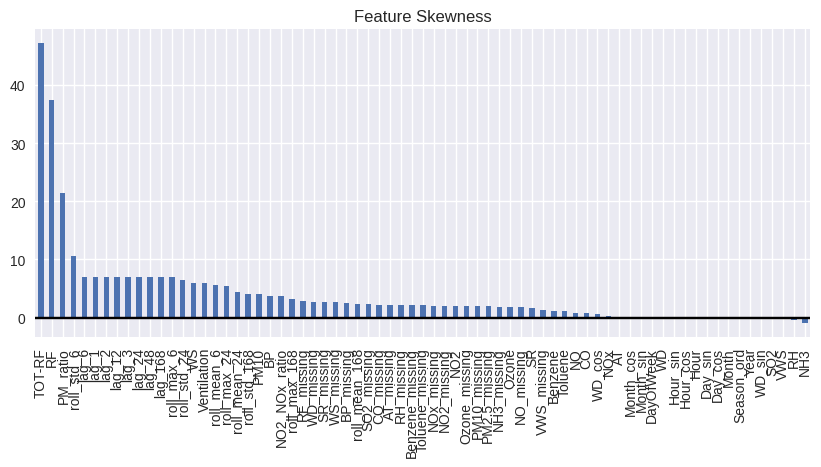

Highly skewed features (>1):
TOT-RF             47.136542
RF                 37.491017
PM_ratio           21.346025
roll_std_6         10.522371
lag_6               7.006220
lag_1               7.004853
lag_2               7.004599
lag_12              7.004565
lag_3               7.004518
lag_24              6.997971
lag_48              6.982249
lag_168             6.981099
roll_max_6          6.925310
roll_std_24         6.485894
WS                  5.975534
Ventilation         5.926179
roll_mean_6         5.557939
roll_max_24         5.502396
roll_mean_24        4.313576
roll_std_168        3.988508
PM10                3.981746
BP                  3.755660
NO2_NOx_ratio       3.680286
roll_max_168        3.176936
RF_missing          2.803591
WD_missing          2.755500
SR_missing          2.700925
WS_missing          2.667468
BP_missing          2.538147
roll_mean_168       2.371651
SO2_missing         2.297979
CO_missing          2.181733
AT_missing          2.174294
RH_missing    

In [147]:
# Skewness values
skew = train[numeric_features].skew().sort_values(ascending=False)

plt.figure(figsize=(10,4))
skew.plot(kind="bar")
plt.title("Feature Skewness")
plt.axhline(0, color="black")
plt.show()

print("Highly skewed features (>1):")
print(skew[abs(skew) > 1])

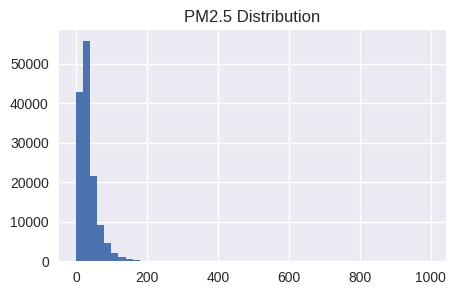

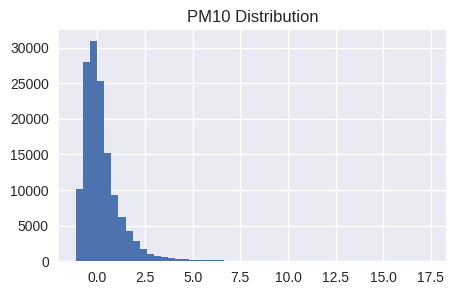

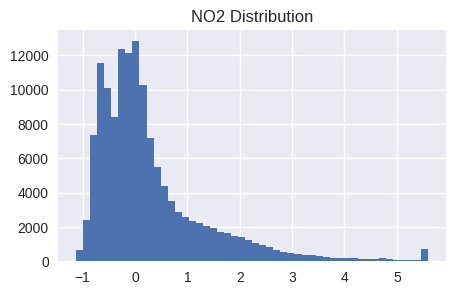

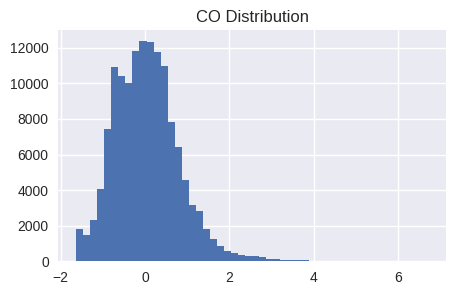

In [148]:
# Plot few important features
cols = ["PM2.5", "PM10", "NO2", "CO"]

for col in cols:
    plt.figure(figsize=(5,3))
    plt.hist(train[col], bins=50)
    plt.title(f"{col} Distribution")
    plt.show()

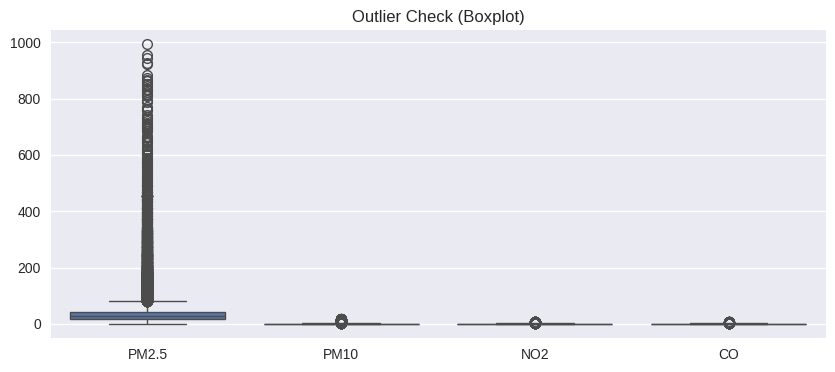

In [149]:
cols = ["PM2.5", "PM10", "NO2", "CO"]

plt.figure(figsize=(10,4))
sns.boxplot(data=train[cols])
plt.title("Outlier Check (Boxplot)")
plt.show()

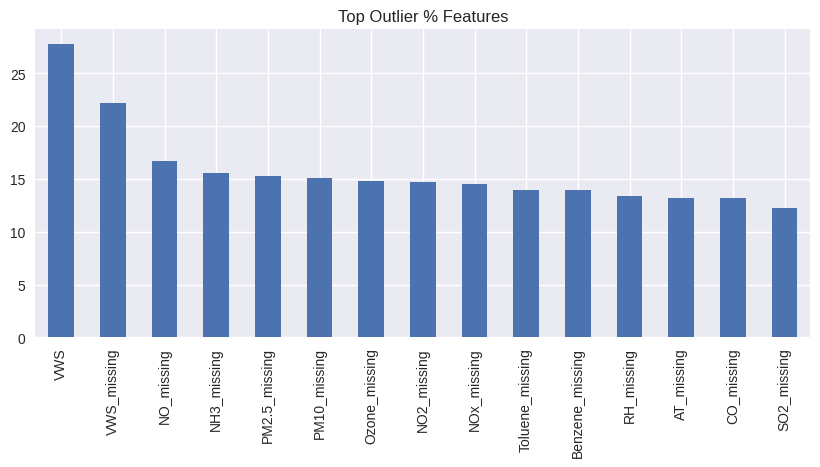

In [150]:
outliers = {}

for col in numeric_features:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    n = ((train[col] < Q1-1.5*IQR) | (train[col] > Q3+1.5*IQR)).sum()
    outliers[col] = n / len(train) * 100

outliers = pd.Series(outliers).sort_values(ascending=False)

plt.figure(figsize=(10,4))
outliers.head(15).plot(kind="bar")
plt.title("Top Outlier % Features")
plt.show()

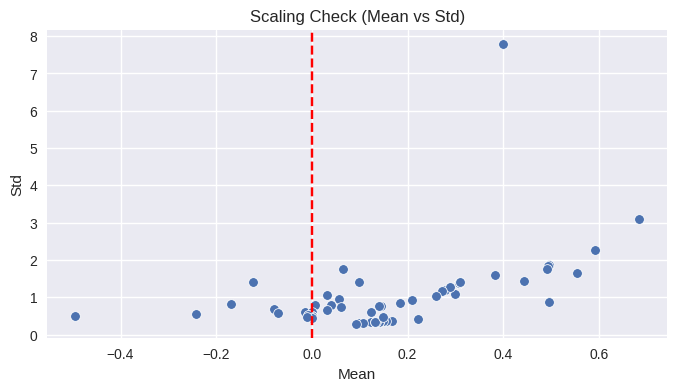

,mean,std
PM10,0.277998,1.206057
NO,0.209455,0.934874
NO2,0.299370,1.086530
NOx,0.057623,0.954540
NH3,-0.168164,0.809389


In [151]:
stats = train[numeric_features].agg(["mean","std"]).T

plt.figure(figsize=(8,4))
sns.scatterplot(x=stats["mean"], y=stats["std"])
plt.axvline(0, color="red", linestyle="--")
plt.title("Scaling Check (Mean vs Std)")
plt.xlabel("Mean")
plt.ylabel("Std")
plt.show()

stats.head()

In [152]:
import pickle

with open("output/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [153]:
import json

with open("output/features.json", "w") as f:
    json.dump({
        "features":         features,
        "numeric_features": numeric_features,
        "target":           TARGET,
        "excluded_from_scaling": ["VWS_direction"],
        "n_train": len(train),
        "n_val":   len(val),
        "n_test":  len(test)
    }, f, indent=2)

print("Features saved:", len(features))

Features saved: 73


In [154]:
train.to_parquet("output/train.parquet", index=False)
val.to_parquet("output/val.parquet", index=False)
test.to_parquet("output/test.parquet", index=False)

print("Saved datasets")

Saved datasets


In [155]:
df.head()

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,roll_mean_6,roll_std_6,roll_max_6,roll_mean_24,roll_std_24,roll_max_24,roll_mean_168,roll_std_168,roll_max_168,City_id
168,2023-01-08 00:00:00,Amaravati,85.50,148.00,1.056053,21.050,2.617396,2.580217,2.395620,0.485508,...,90.541667,10.119803,103.75,99.969167,15.365038,120.5,68.447004,27.563693,131.25,0
169,2023-01-08 01:00:00,Amaravati,89.50,155.00,0.799757,15.375,2.319934,2.756840,3.217875,0.537954,...,92.250000,7.564721,103.75,99.125417,15.588170,120.5,68.702956,27.520923,131.25,0
170,2023-01-08 02:00:00,Amaravati,86.00,148.25,0.705570,15.525,2.312535,2.739226,3.190476,0.648411,...,92.625000,7.319068,103.75,98.354583,15.587654,120.5,68.987183,27.487448,131.25,0
171,2023-01-08 03:00:00,Amaravati,79.75,147.25,1.020651,20.450,2.591516,2.574519,3.212858,0.636577,...,92.291667,7.611532,103.75,97.458750,15.656865,120.5,69.234206,27.452523,131.25,0
172,2023-01-08 04:00:00,Amaravati,75.25,146.50,0.993252,18.225,2.491137,2.658510,3.167583,0.569566,...,88.958333,8.058251,103.75,96.302500,15.905766,120.5,69.411290,27.423645,131.25,0


In [156]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139008 entries, 168 to 201671
Data columns (total 77 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date             139008 non-null  datetime64[ns]
 1   City             139008 non-null  object        
 2   PM2.5            139008 non-null  float64       
 3   PM10             139008 non-null  float64       
 4   NO               139008 non-null  float64       
 5   NO2              139008 non-null  float64       
 6   NOx              139008 non-null  float64       
 7   NH3              139008 non-null  float64       
 8   SO2              139008 non-null  float64       
 9   CO               139008 non-null  float64       
 10  Ozone            139008 non-null  float64       
 11  Benzene          139008 non-null  float64       
 12  Toluene          139008 non-null  float64       
 13  RH               139008 non-null  float64       
 14  WS               139008

In [157]:
cols_to_drop = (
    [c for c in train.columns if "_missing" in c] +
    ["Date", "City", "Season"]
)

train_ml = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
val_ml   = val.drop(columns=[c for c in cols_to_drop if c in val.columns])
test_ml  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

train_ml.to_csv("output/train_ml.csv", index=False)
val_ml.to_csv("output/val_ml.csv",     index=False)
test_ml.to_csv("output/test_ml.csv",   index=False)

print("Train ML shape:", train_ml.shape)
print("Val   ML shape:", val_ml.shape)
print("Test  ML shape:", test_ml.shape)
print("Columns:", train_ml.columns.tolist())

Train ML shape: (139008, 55)
Val   ML shape: (52416, 55)
Test  ML shape: (17664, 55)
Columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone', 'Benzene', 'Toluene', 'RH', 'WS', 'WD', 'SR', 'BP', 'VWS', 'TOT-RF', 'RF', 'AT', 'Month', 'Hour', 'VWS_direction', 'PM_ratio', 'NO2_NOx_ratio', 'Ventilation', 'Season_ord', 'DayOfWeek', 'Year', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'WD_sin', 'WD_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'roll_mean_6', 'roll_std_6', 'roll_max_6', 'roll_mean_24', 'roll_std_24', 'roll_max_24', 'roll_mean_168', 'roll_std_168', 'roll_max_168', 'City_id']


In [158]:
print("=== Split Summary ===")
print(f"Train: {len(train_ml):,} rows | Years: {train['Year'].min()}–{train['Year'].max()}")
print(f"Val  : {len(val_ml):,} rows | Months: {val['Month'].min()}–{val['Month'].max()} (2025)")
print(f"Test : {len(test_ml):,} rows | Months: {test['Month'].min()}–{test['Month'].max()} (2025)")
print(f"\nCities in train: {sorted(train['City'].unique())}")
print(f"Cities in val  : {sorted(val['City'].unique())}")
print(f"Cities in test : {sorted(test['City'].unique())}")

=== Split Summary ===
Train: 139,008 rows | Years: -1.0–0.0
Val  : 52,416 rows | Months: -1.0–0.3333333333333333 (2025)
Test : 17,664 rows | Months: 0.5–0.8333333333333334 (2025)

Cities in train: ['Amaravati', 'Anantapur', 'Chittoor', 'Kadapa', 'Rajamahendravaram', 'Tirupati', 'Vijayawada', 'Visakhapatnam']
Cities in val  : ['Amaravati', 'Anantapur', 'Chittoor', 'Kadapa', 'Rajamahendravaram', 'Tirupati', 'Vijayawada', 'Visakhapatnam']
Cities in test : ['Amaravati', 'Anantapur', 'Chittoor', 'Kadapa', 'Rajamahendravaram', 'Tirupati', 'Vijayawada', 'Visakhapatnam']


In [159]:
import json

reverse_city_map = {str(v): k for k, v in city_map.items()}

with open("output/city_map.json", "w") as f:
    json.dump(reverse_city_map, f, indent=2)

print("City map saved:")
for city_id, city_name in sorted(reverse_city_map.items(), key=lambda x: int(x[0])):
    print(f"  {city_id} → {city_name}")

City map saved:
  0 → Amaravati
  1 → Anantapur
  2 → Chittoor
  3 → Kadapa
  4 → Rajamahendravaram
  5 → Tirupati
  6 → Vijayawada
  7 → Visakhapatnam
